In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd 
import os

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "parasharmanu/close-to-realistic-calorie-efficiency-dataset",
    "calorie_efficiency_dataset.csv",
    )

# Step 1 - EDA

In [2]:
df

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,55,5881,81,1500,4.06,1.91,25.66,5,0.322,0.101,70.0,110.8,2,0.387,Low Efficiency
999996,53,3303,41,1500,6.65,1.58,26.21,1,0.200,0.329,67.4,111.3,1,1.393,Low Efficiency
999997,28,8553,62,1500,5.33,3.86,20.70,4,0.426,0.339,61.4,119.0,1,0.515,Low Efficiency
999998,34,6936,52,1500,8.52,1.58,21.95,7,0.251,0.332,64.9,107.0,2,0.595,Low Efficiency


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                       1000000 non-null  float64
 7   workouts_per_week         1000000 non-null  int64  
 8   muscle_mass_ratio         1000000 non-null  float64
 9   body_fat_percentage       1000000 non-null  float64
 10  heart_rate_resting        1000000 non-null  float64
 11  heart_rate_avg            1000000 non-null  float64
 12  continuous_exercise_days  1000000 non-null  int64  
 13  efficiency_score          10

Data type for each feature looks correct.

In [4]:
(df.isnull().sum()/(len(df)))*100

age                         0.0
steps_per_day               0.0
active_minutes              0.0
calories_burned             0.0
sleep_hours                 0.0
hydration_liters            0.0
bmi                         0.0
workouts_per_week           0.0
muscle_mass_ratio           0.0
body_fat_percentage         0.0
heart_rate_resting          0.0
heart_rate_avg              0.0
continuous_exercise_days    0.0
efficiency_score            0.0
calorie_efficiency          0.0
dtype: float64

There are no null values.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,40.982084,13.550471,18.00,29.000,41.00,53.000,64.0
steps_per_day,1000000.0,7001.232915,2482.813116,1000.00,5309.000,6993.00,8683.000,18924.0
active_minutes,1000000.0,69.673644,28.602711,10.00,50.000,69.00,89.000,180.0
calories_burned,1000000.0,1500.000000,0.000000,1500.00,1500.000,1500.00,1500.000,1500.0
sleep_hours,1000000.0,6.500965,1.196880,3.00,5.690,6.50,7.310,10.0
hydration_liters,1000000.0,2.502449,0.794725,0.50,1.960,2.50,3.040,5.0
bmi,1000000.0,24.221054,5.372620,16.00,20.070,24.01,27.950,40.0
workouts_per_week,1000000.0,2.984637,1.683523,0.00,2.000,3.00,4.000,7.0
muscle_mass_ratio,1000000.0,0.350857,0.077842,0.20,0.296,0.35,0.404,0.6
body_fat_percentage,1000000.0,0.250580,0.097494,0.05,0.182,0.25,0.317,0.5


# Step 2 - EDA graph plot

In [6]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['calorie_efficiency'], dtype='object')
Numerical Variables:
Index(['age', 'steps_per_day', 'active_minutes', 'calories_burned',
       'sleep_hours', 'hydration_liters', 'bmi', 'workouts_per_week',
       'muscle_mass_ratio', 'body_fat_percentage', 'heart_rate_resting',
       'heart_rate_avg', 'continuous_exercise_days', 'efficiency_score'],
      dtype='object')


age
Skew : 0.0


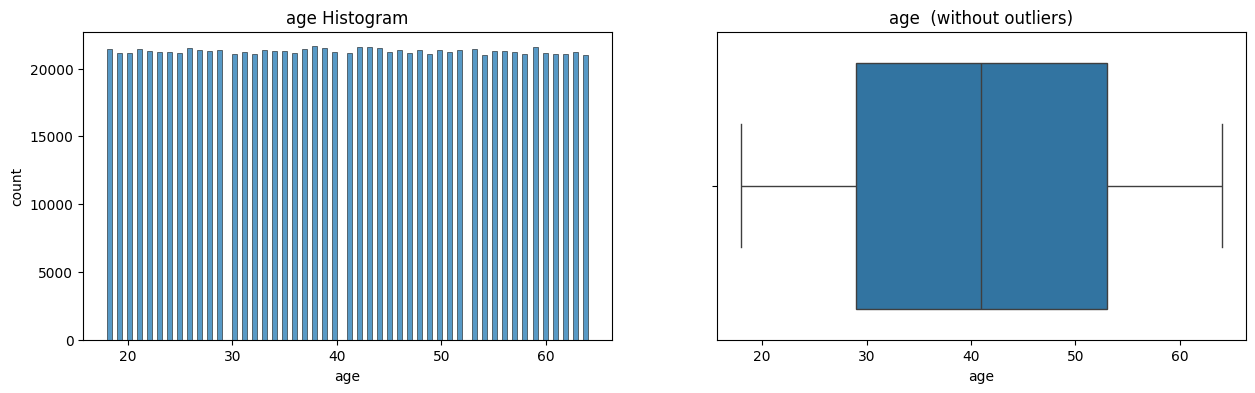

steps_per_day
Skew : 0.05


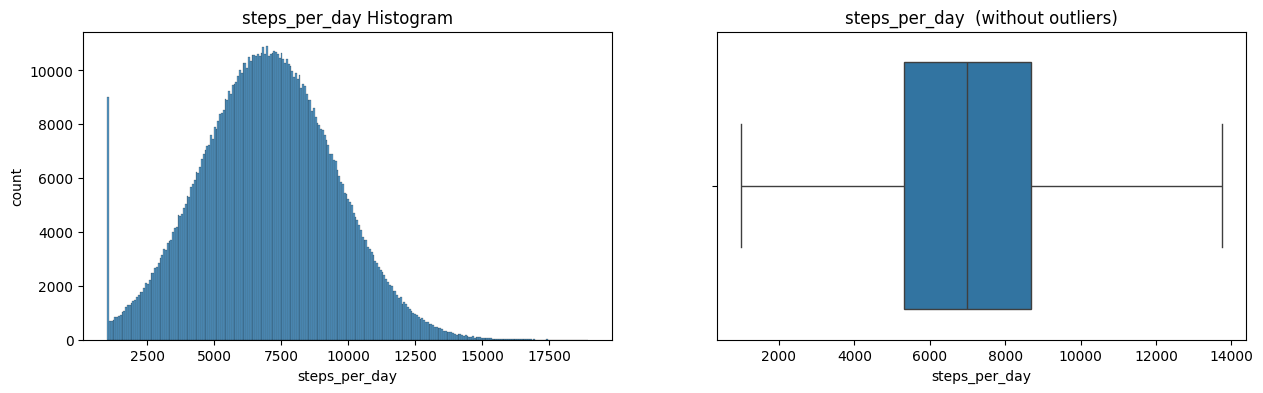

active_minutes
Skew : 0.12


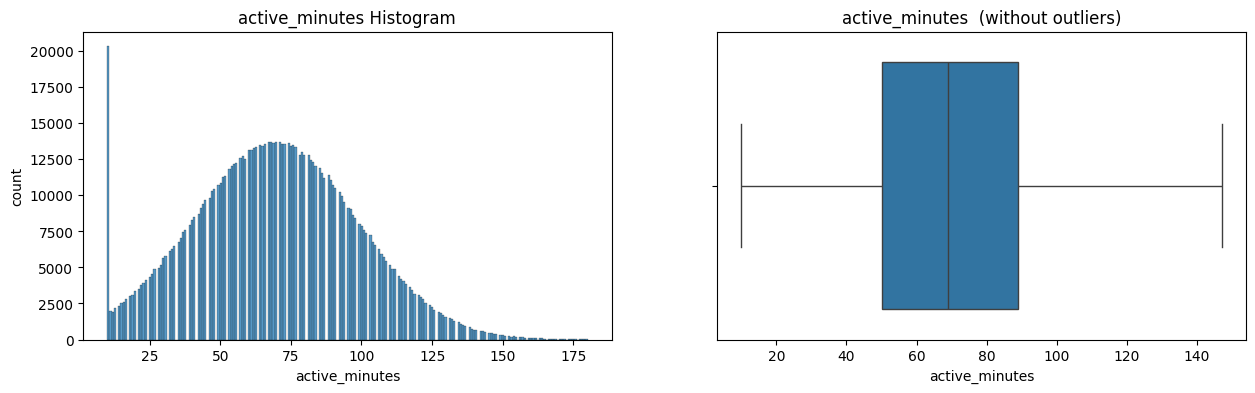

calories_burned
Skew : 0.0


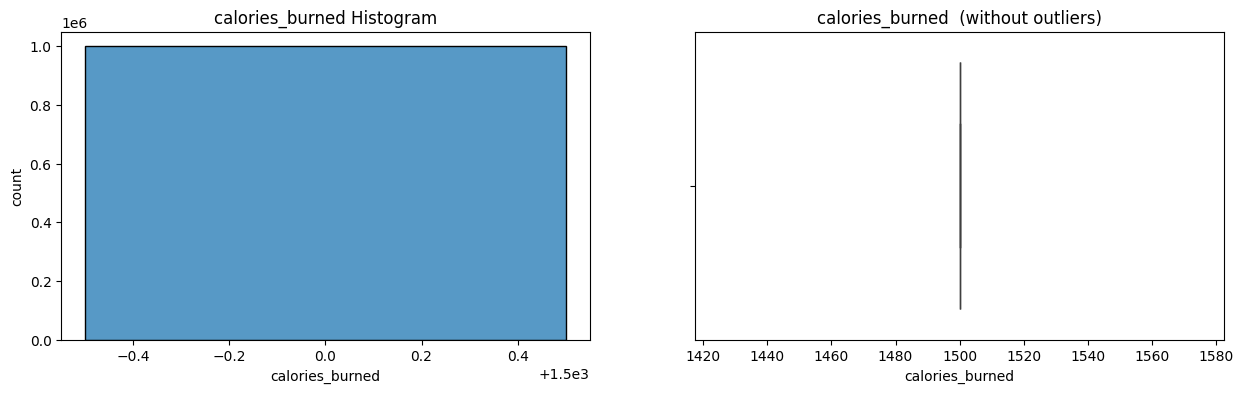

sleep_hours
Skew : 0.0


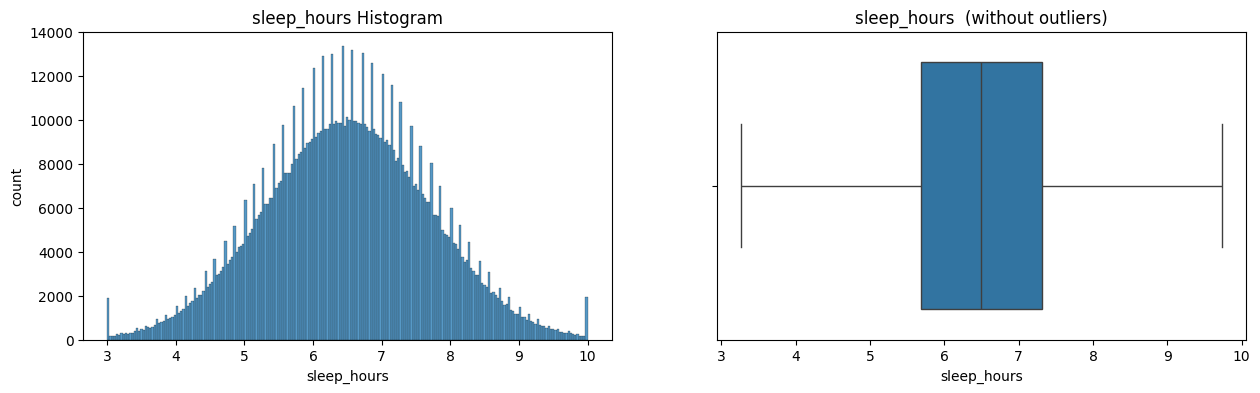

hydration_liters
Skew : 0.04


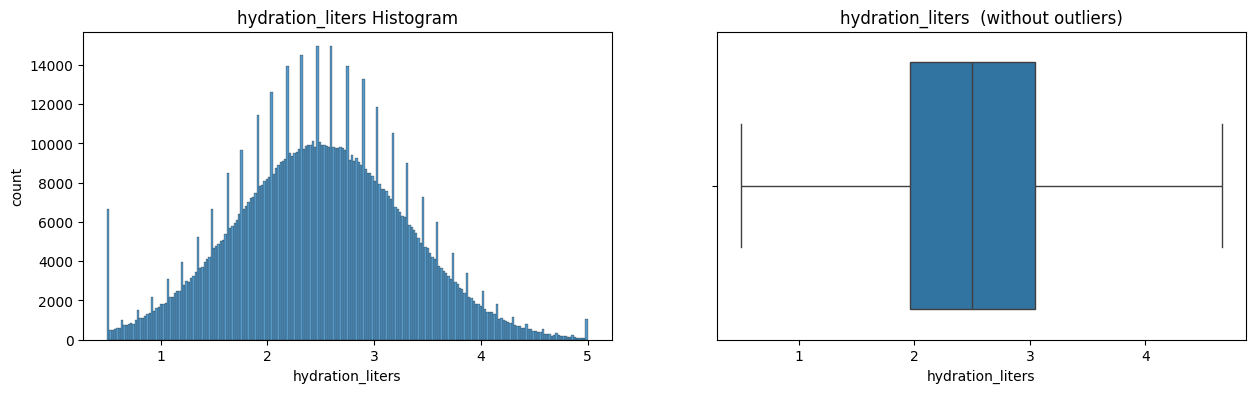

bmi
Skew : 0.31


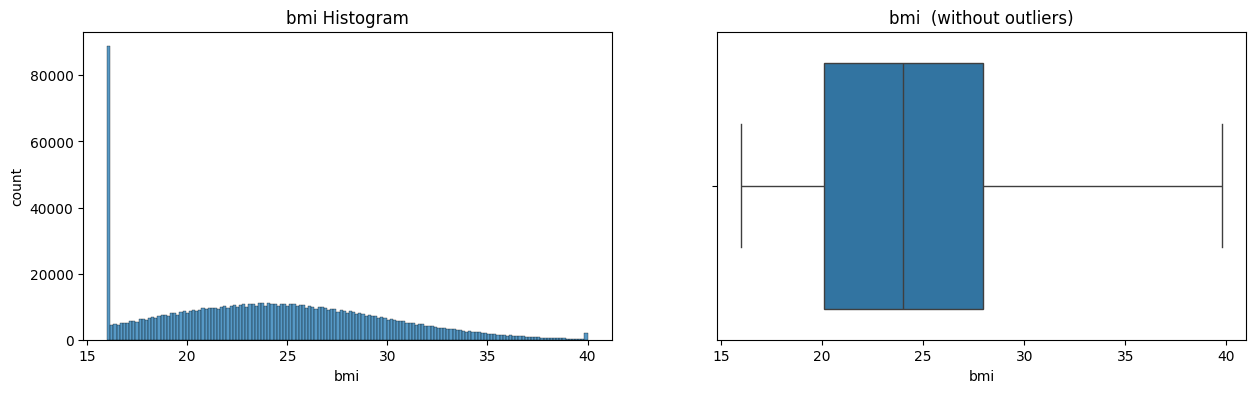

workouts_per_week
Skew : 0.39


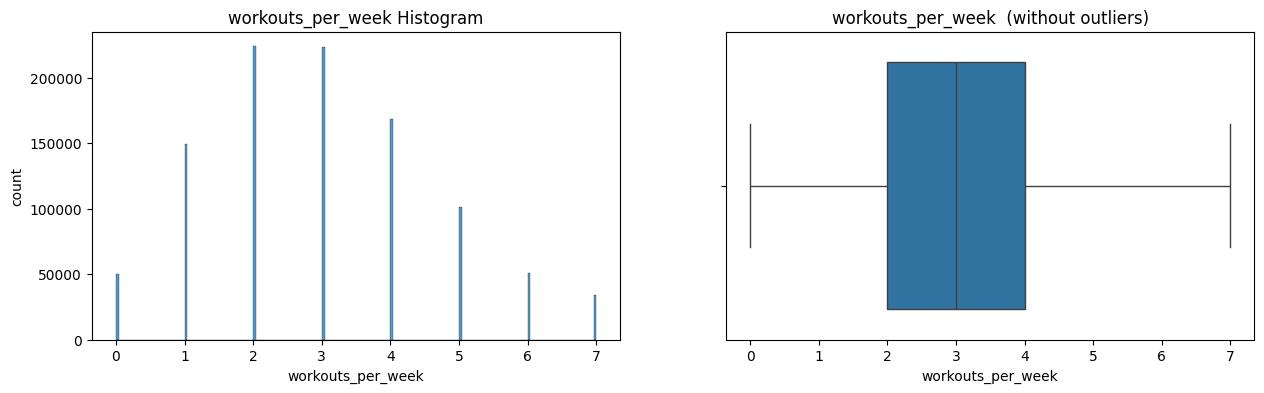

muscle_mass_ratio
Skew : 0.15


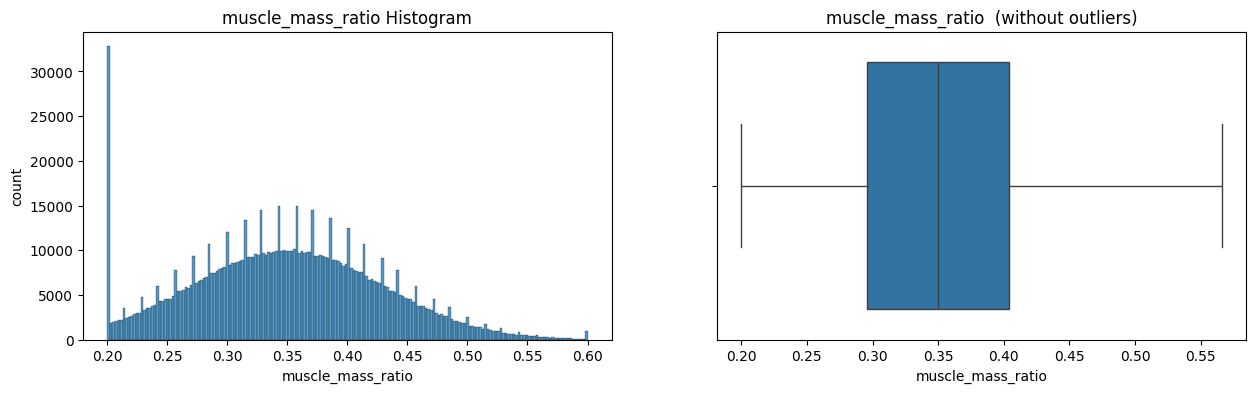

body_fat_percentage
Skew : 0.08


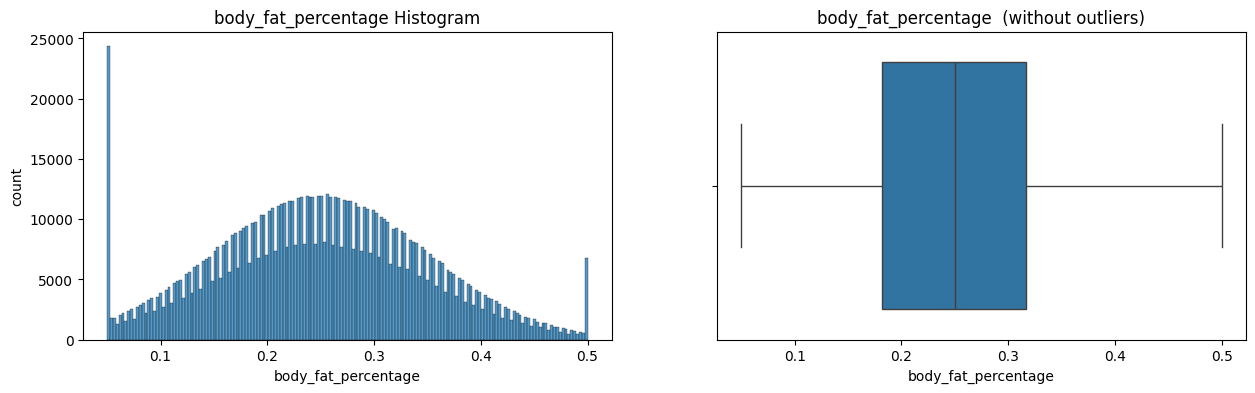

heart_rate_resting
Skew : -0.01


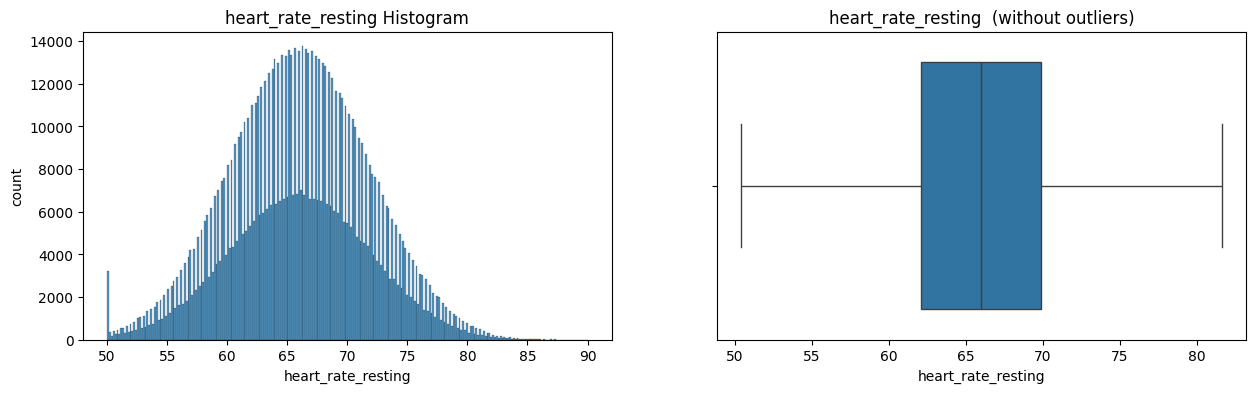

heart_rate_avg
Skew : 0.07


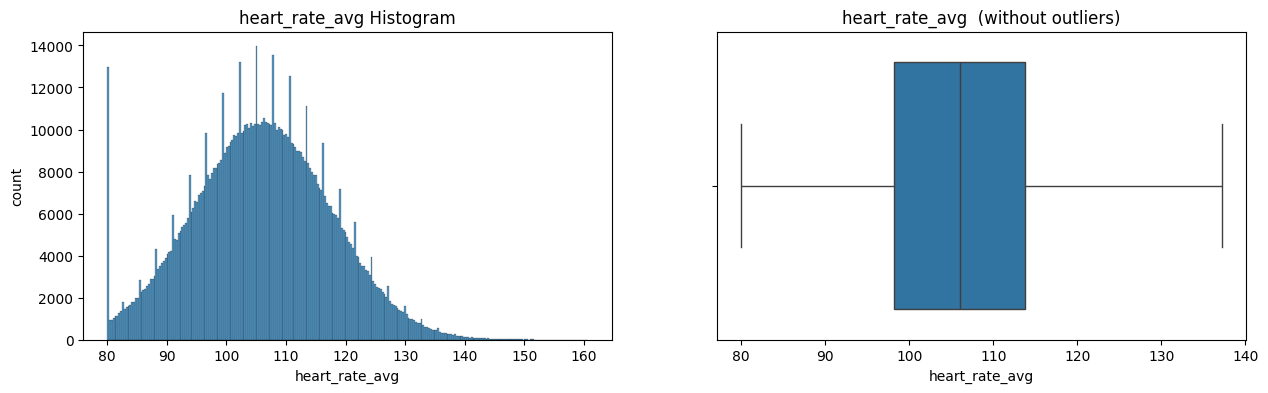

continuous_exercise_days
Skew : 1.24


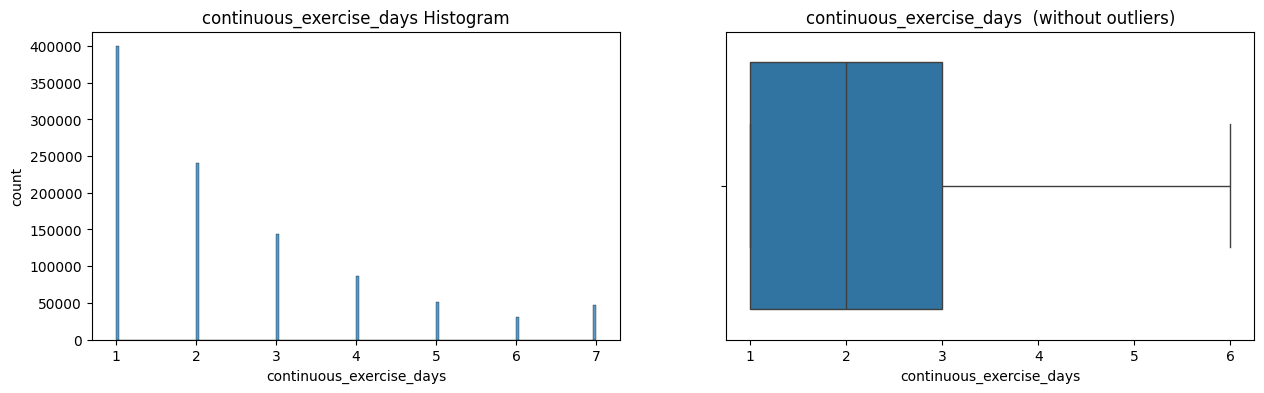

efficiency_score
Skew : 3.95


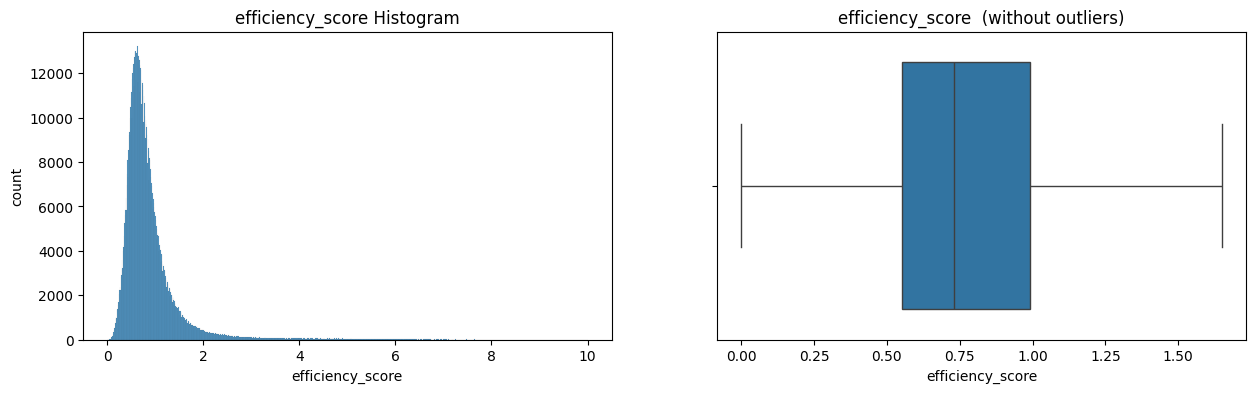

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f'{col}  (without outliers)')
    
    plt.show()

We are seeing a lot of normality for most metrics, except the efficiency score.

The efficiency score is very slightly skewed to the right.

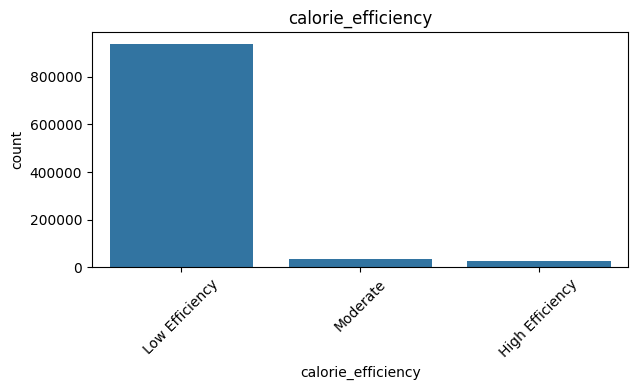

In [8]:
import math 

plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

The majority of the records have low effiency.

# Step 4 - Bivariate Analysis

/tmp/ipykernel_7277/2148987740.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


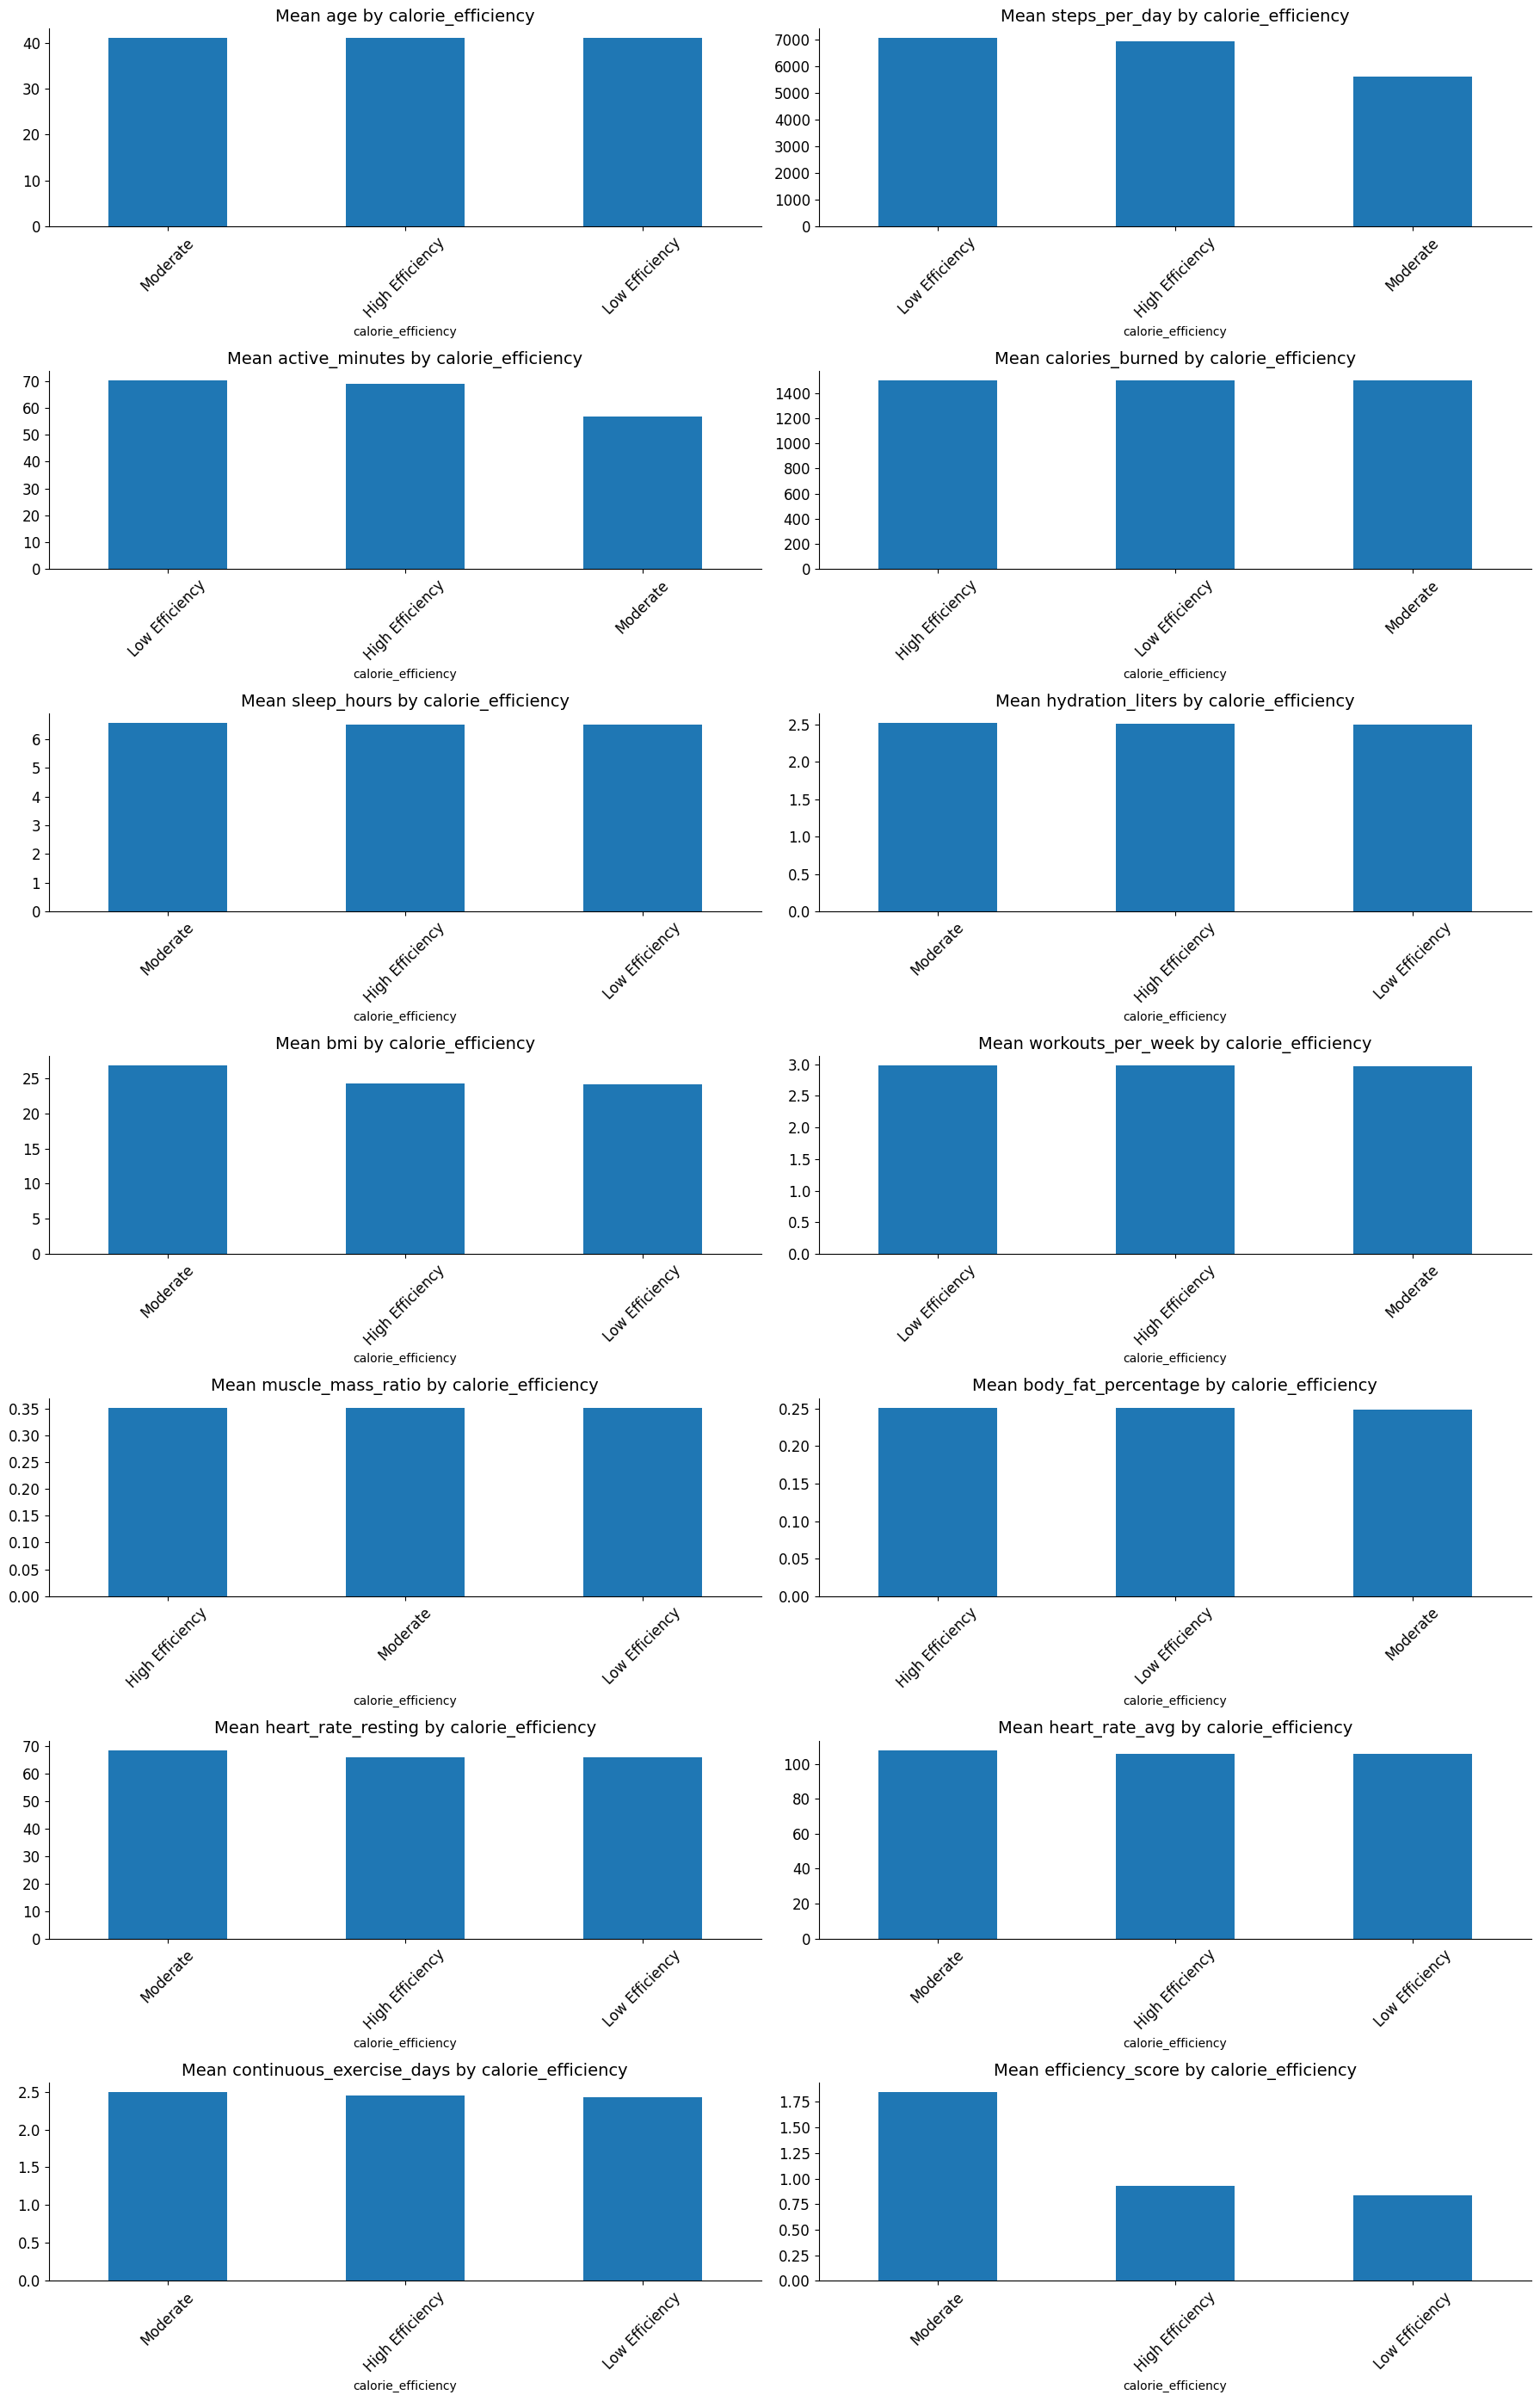

In [9]:
nrows, ncols = 7, 2

fig_h = nrows * 4.0 
fig_w = 18

fig, axarr = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), constrained_layout=True)
axes = axarr.ravel()

for i, num_col in enumerate(num_cols):
    (df.groupby('calorie_efficiency')[num_col]
       .mean()
       .sort_values(ascending=False)
       .plot(kind='bar', ax=axes[i], fontsize=12))

    axes[i].set_title(f"Mean {num_col} by calorie_efficiency", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, nrows*ncols):
    axes[j].axis('off')

plt.tight_layout()
sns.despine()

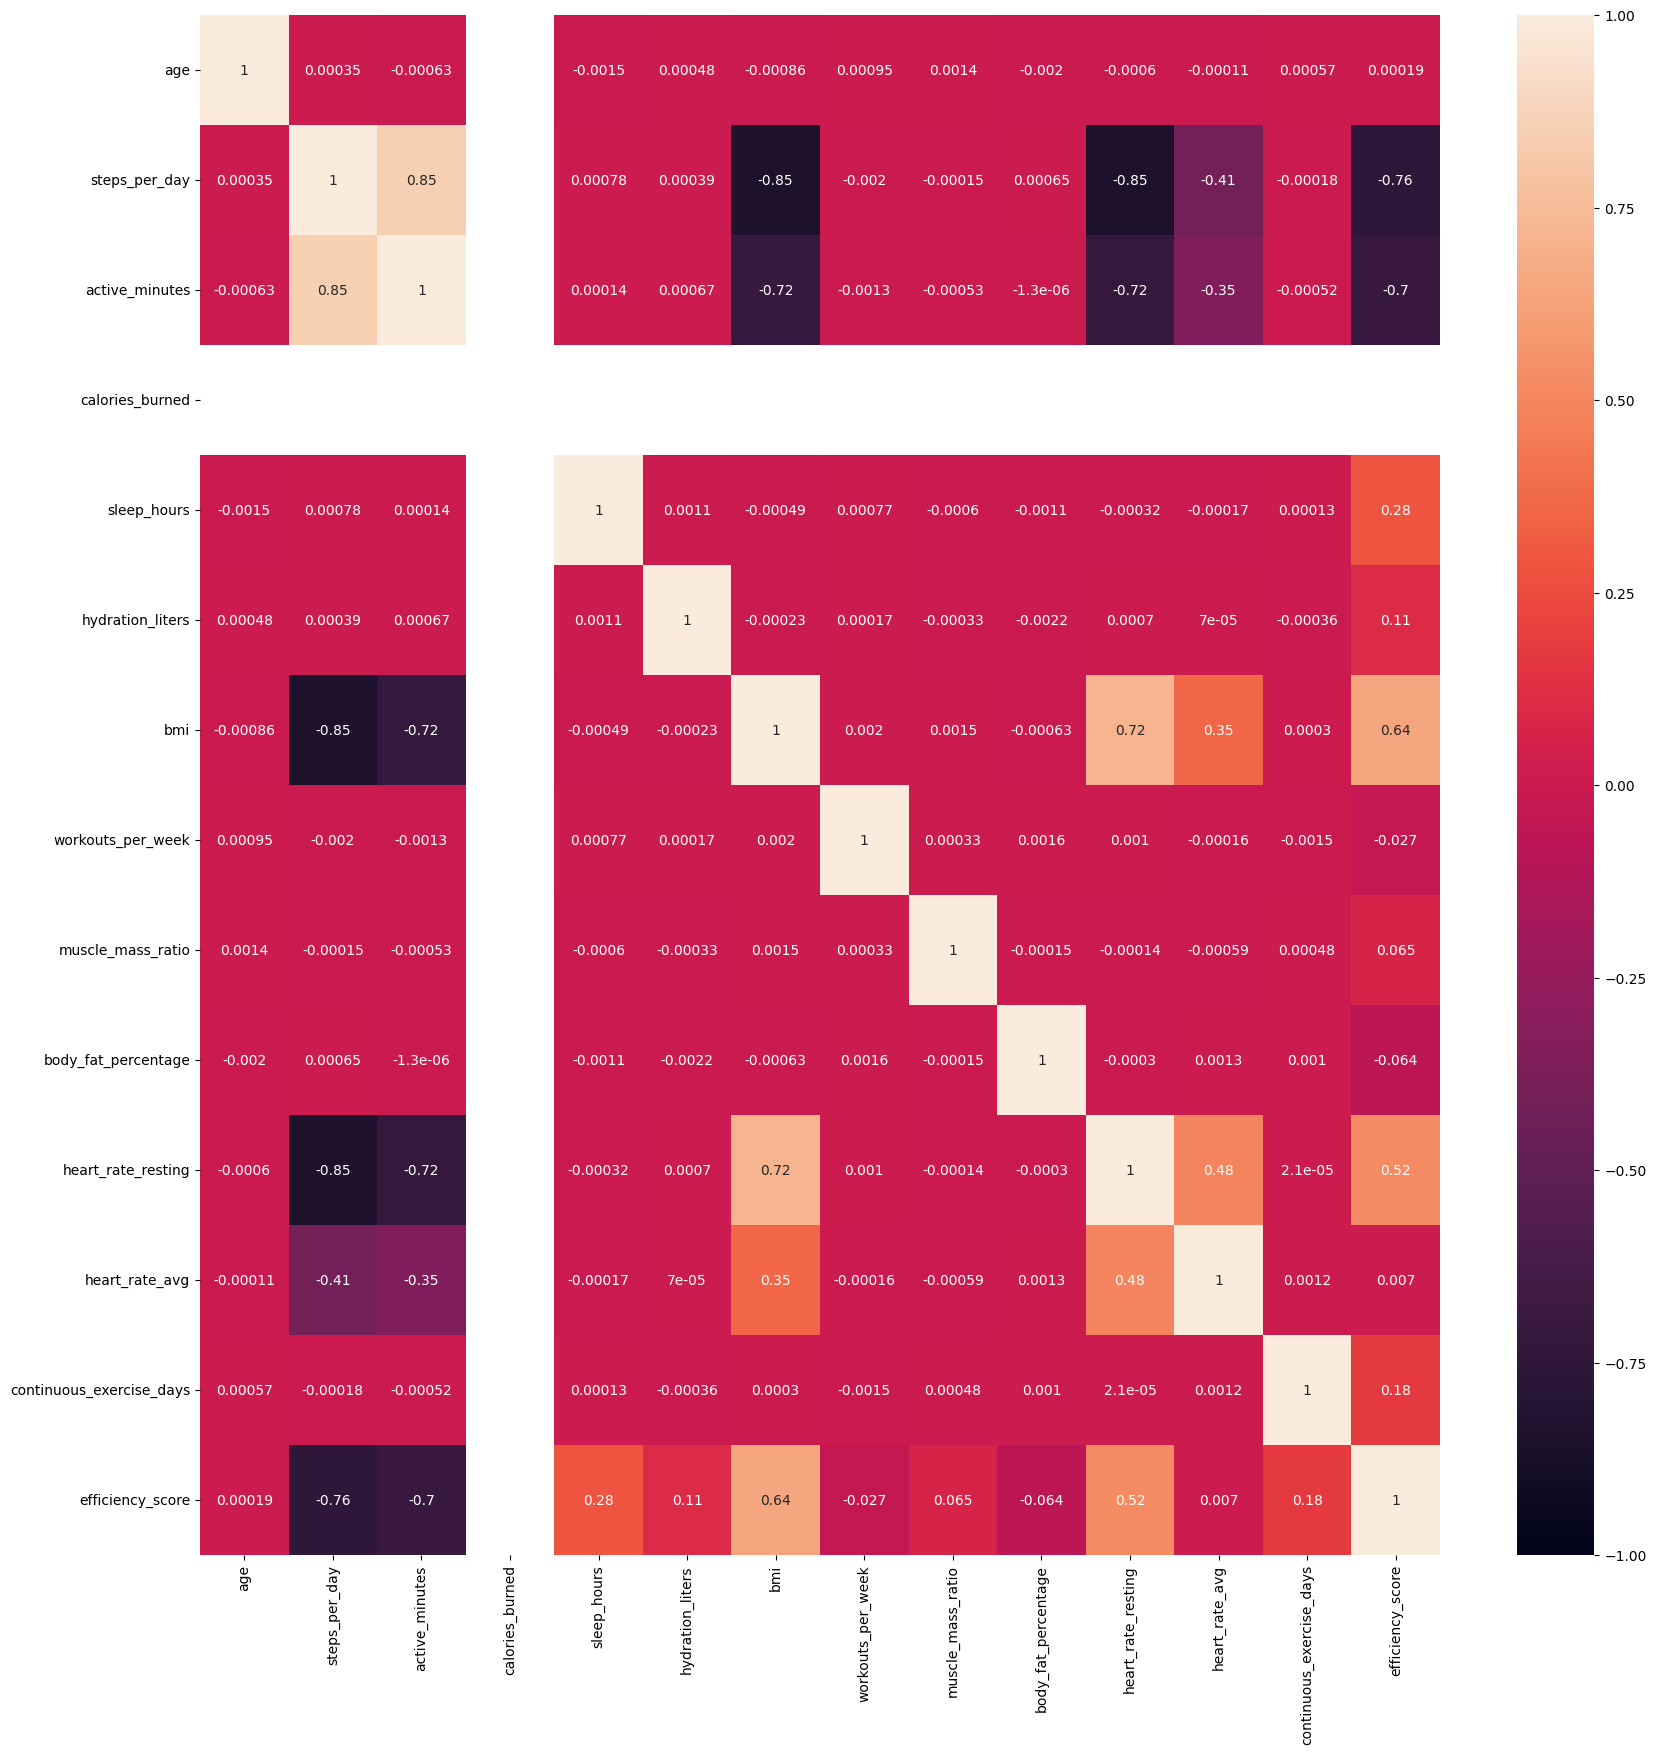

In [10]:
plt.figure(figsize=(20, 20))
sns.heatmap(df[num_cols].corr(method='spearman'), annot = True, vmin = -1, vmax = 1)
plt.show()

### According to the documentation, efficiency is not determined by the amount of effort expended, but rather by the calories burned for that same effort. This explains the negative correlation between the number of steps taken and efficiency.

# Step 5 - Prepare data & Hyperparameter tuning

In [15]:
df_small = df.sample(n=30000)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_small.drop(['calorie_efficiency'], axis=1))

In [17]:
X_scaled

array([[ 0.59324255,  0.72993177,  1.72702039, ..., -1.62099879,
        -0.25650106, -0.35238548],
       [ 0.37093314,  0.61602623,  0.3903409 , ..., -0.70248014,
         0.33748056, -0.11658981],
       [-0.2959951 ,  0.4944462 , -0.13729574, ..., -0.36131607,
         0.93146218, -0.26517339],
       ...,
       [ 1.48248021, -1.97027585, -1.57950257, ...,  2.50796121,
        -0.85048269,  1.29979924],
       [ 1.18606765,  0.69357894,  0.21446202, ...,  0.76714969,
        -0.25650106, -0.58495108],
       [-0.37009824, -1.56675941, -0.77045972, ...,  0.33850765,
         0.33748056,  1.0736938 ]], shape=(30000, 14))

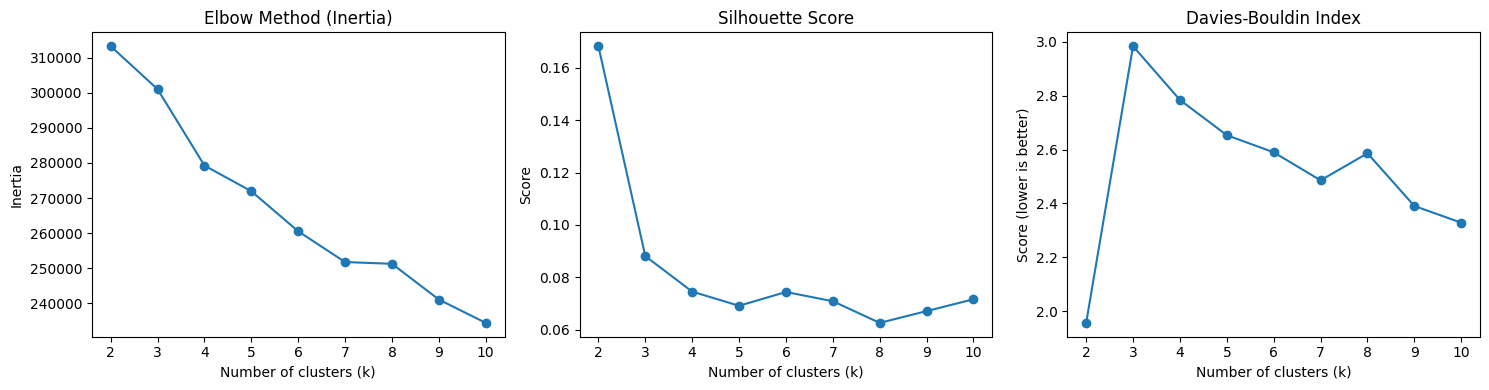

Best k by Silhouette Score: 2
Best k by Davies-Bouldin Index: 2


In [18]:
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Range of k values to test
# -----------------------------
k_values = range(2, 11)

inertia = []
silhouette_scores = []
db_scores = []

# -----------------------------
# Run k-means for each k
# -----------------------------
for k in k_values:

    kmeans = MiniBatchKMeans(init ='k-means++', n_clusters = k,
                      batch_size = 1000)
    labels = kmeans.fit_predict(X_scaled)
    
    # Elbow method (inertia)
    inertia.append(kmeans.inertia_)
    
    # Silhouette score
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    
    # Davies-Bouldin index
    db = davies_bouldin_score(X_scaled, labels)
    db_scores.append(db)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(15, 4))

# 1. Elbow plot
plt.subplot(1, 3, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

# 2. Silhouette score
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')

# 3. Davies-Bouldin index
plt.subplot(1, 3, 3)
plt.plot(k_values, db_scores, marker='o')
plt.title('Davies-Bouldin Index')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score (lower is better)')

plt.tight_layout()
plt.show()

# -----------------------------
# Print best k suggestions
# -----------------------------
best_silhouette_k = k_values[np.argmax(silhouette_scores)]
best_db_k = k_values[np.argmin(db_scores)]

print(f"Best k by Silhouette Score: {best_silhouette_k}")
print(f"Best k by Davies-Bouldin Index: {best_db_k}")